<h2>Importing The Libraries</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

import warnings
warnings.filterwarnings('ignore')

## Load Movie Dataset

In [4]:
movies = pd.read_csv(
    'movie_titles.csv',
    encoding='latin1',
    header=None,
    names=['Movie_ID', 'Year', 'Movie_Name'],
    on_bad_lines='skip'
)

movies.head()

,Movie_ID,Year,Movie_Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


## Load Ratings Dataset

In [6]:
ratings_list = []

movie_id = None
count = 0

limit = 500000

with open('combined_data_1.txt', 'r') as file:

    for line in file:

        line = line.strip()

        if ':' in line:

            movie_id = int(line.replace(':', ''))

        else:

            user_id, rating, date = line.split(',')

            ratings_list.append([
                int(user_id),
                movie_id,
                int(rating)
            ])

            count += 1

            if count >= limit:
                break

ratings = pd.DataFrame(
    ratings_list,
    columns=['User_ID', 'Movie_ID', 'Rating']
)

ratings.head()

,User_ID,Movie_ID,Rating
0,1488844,1,3
1,822109,1,5
2,885013,1,4
3,30878,1,4
4,823519,1,3


## Merge Datasets

In [8]:
netflix_data = pd.merge(
    ratings,
    movies,
    on='Movie_ID'
)

netflix_data.head()

,User_ID,Movie_ID,Rating,Year,Movie_Name
0,1488844,1,3,2003.0,Dinosaur Planet
1,822109,1,5,2003.0,Dinosaur Planet
2,885013,1,4,2003.0,Dinosaur Planet
3,30878,1,4,2003.0,Dinosaur Planet
4,823519,1,3,2003.0,Dinosaur Planet


## Dataset Information

In [10]:
print("Dataset Shape:")
print(netflix_data.shape)

print("\nMissing Values:")
print(netflix_data.isnull().sum())

print("\nStatistical Summary:")
print(netflix_data.describe())

Dataset Shape:
(499821, 5)

Missing Values:
User_ID       0
Movie_ID      0
Rating        0
Year          0
Movie_Name    0
dtype: int64

Statistical Summary:
            User_ID       Movie_ID         Rating           Year
count  4.998210e+05  499821.000000  499821.000000  499821.000000
mean   1.323667e+06      65.968773       3.546021    1997.068104
std    7.644098e+05      42.993728       1.079028      10.602207
min    6.000000e+00       1.000000       1.000000    1927.000000
25%    6.617300e+05      30.000000       3.000000    1996.000000
50%    1.320564e+06      52.000000       4.000000    2002.000000
75%    1.985381e+06     108.000000       4.000000    2003.000000
max    2.649429e+06     148.000000       5.000000    2005.000000


## Top Rated & Most Watched Movies

In [12]:
top_rated_movies = netflix_data.groupby(
    'Movie_Name'
)['Rating'].mean().sort_values(
    ascending=False
)

most_watched_movies = netflix_data.groupby(
    'Movie_Name'
)['Rating'].count().sort_values(
    ascending=False
)

print("Top Rated Movies:\n")
print(top_rated_movies.head(10))

print("\nMost Watched Movies:\n")
print(most_watched_movies.head(10))

Top Rated Movies:

Movie_Name
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material    4.552000
Elfen Lied                                                                     4.251880
Aqua Teen Hunger Force: Vol. 1                                                 4.168650
Invader Zim                                                                    4.142599
GTO: Great Teacher Onizuka: Set 2                                              4.138021
Stevie Ray Vaughan and Double Trouble: Live at Montreux 1982 & 1985            4.097872
I Love Lucy: Season 2                                                          4.090386
ABC Primetime: Mel Gibson's The Passion of the Christ                          4.071737
Zatoichi's Conspiracy                                                          3.989324
Inspector Morse 31: Death Is Now My Neighbour                                  3.970174
Name: Rating, dtype: float64

Most Watched Movies:

Movie_Name
Something's Gotta Give     

## Ratings Distribution Graph

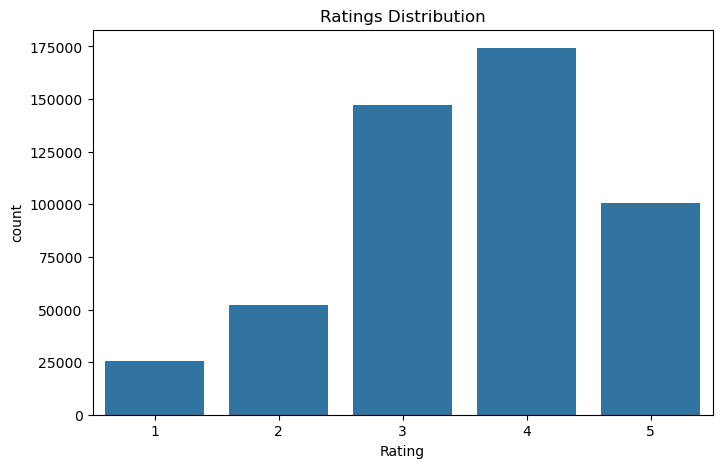

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Rating',
    data=netflix_data
)

plt.title("Ratings Distribution")

plt.show()

## Popular Movies Graph

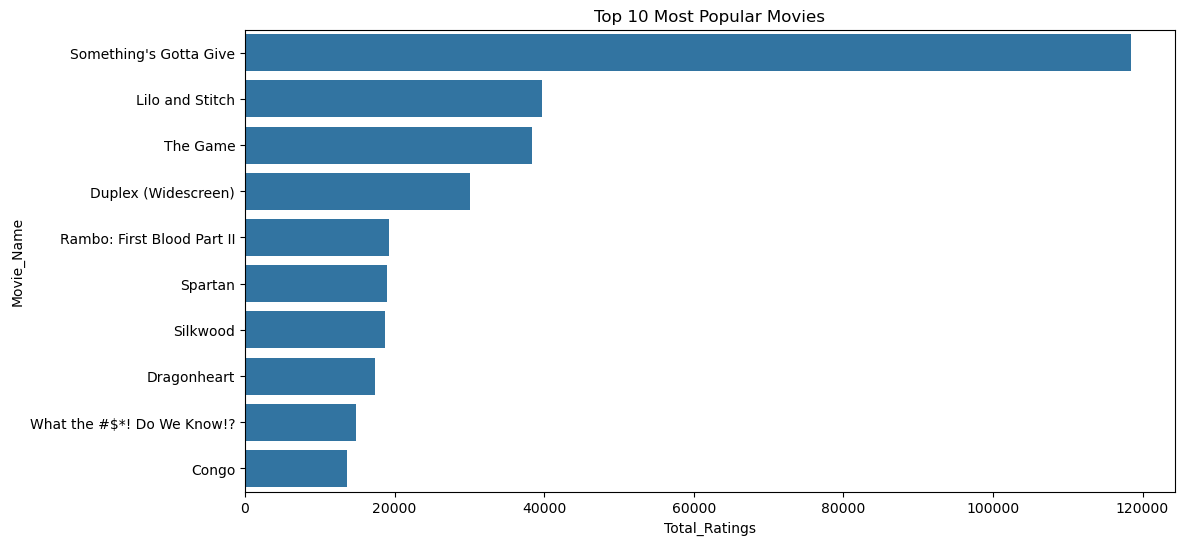

In [16]:
movie_ratings = netflix_data.groupby(
    'Movie_Name'
).agg({
    'Rating':'mean',
    'User_ID':'count'
})

movie_ratings.rename(
    columns={'User_ID':'Total_Ratings'},
    inplace=True
)

popular_movies = movie_ratings.sort_values(
    'Total_Ratings',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=popular_movies['Total_Ratings'],
    y=popular_movies.index
)

plt.title("Top 10 Most Popular Movies")

plt.show()

## Recommendation Engine Using SVD

In [18]:
from scipy.sparse.linalg import svds

# TOP ACTIVE USERS
active_users = netflix_data['User_ID'].value_counts().head(1000).index

filtered_data = netflix_data[
    netflix_data['User_ID'].isin(active_users)
]

# USER MOVIE MATRIX
user_movie_matrix = filtered_data.pivot_table(
    index='User_ID',
    columns='Movie_Name',
    values='Rating'
).fillna(0)

# CONVERT TO MATRIX
matrix = user_movie_matrix.values

# APPLY SVD
U, sigma, Vt = svds(matrix, k=50)

# DIAGONAL MATRIX
sigma = np.diag(sigma)

# PREDICTED RATINGS
predicted_ratings = np.dot(
    np.dot(U, sigma),
    Vt
)

# CREATE DATAFRAME
predicted_df = pd.DataFrame(
    predicted_ratings,
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

print("SVD Model Applied Successfully")

SVD Model Applied Successfully


## Top 5 Movie Recommendations Using SVD

In [20]:
def recommend_movies_svd(user_id, num_recommendations=5):

    user_row_number = predicted_df.index.tolist().index(user_id)

    sorted_user_predictions = predicted_df.iloc[
        user_row_number
    ].sort_values(ascending=False)

    user_data = filtered_data[
        filtered_data['User_ID'] == user_id
    ]

    watched_movies = user_data['Movie_Name'].tolist()

    recommendations = []

    for movie in sorted_user_predictions.index:

        if movie not in watched_movies:

            recommendations.append({
                'Movie_Name': movie,
                'Estimated_Score': round(
                    sorted_user_predictions[movie],
                    2
                )
            })

        if len(recommendations) == num_recommendations:
            break

    return pd.DataFrame(recommendations)


# SAMPLE USER
sample_user = filtered_data['User_ID'].iloc[0]

print("Recommendations for User:", sample_user)

recommend_movies_svd(sample_user)

Recommendations for User: 1488844


,Movie_Name,Estimated_Score
0,By Dawn's Early Light,0.79
1,Inside the Space Station,0.74
2,Chain of Command,0.52
3,Sanford and Son: Season 6,0.52
4,Sick,0.44


In [34]:
movie_stats = netflix_data.groupby('Movie_Name')['Rating'].agg(['mean', 'count'])

min_ratings_threshold = 100
filtered_movies = movie_stats[movie_stats['count'] >= min_ratings_threshold]

best_movies = filtered_movies.sort_values(by='mean', ascending=False)
worst_movies = filtered_movies.sort_values(by='mean', ascending=True)

print("⭐ Top 10 Best Rated Movies (with min 100 ratings):\n")
print(best_movies['mean'].head(10))

print("\n📉 Top 10 Worst Rated Movies (with min 100 ratings):\n")
print(worst_movies['mean'].head(10))

⭐ Top 10 Best Rated Movies (with min 100 ratings):

Movie_Name
Lord of the Rings: The Return of the King: Extended Edition: Bonus Material    4.552000
Elfen Lied                                                                     4.251880
Aqua Teen Hunger Force: Vol. 1                                                 4.168650
Invader Zim                                                                    4.142599
GTO: Great Teacher Onizuka: Set 2                                              4.138021
Stevie Ray Vaughan and Double Trouble: Live at Montreux 1982 & 1985            4.097872
I Love Lucy: Season 2                                                          4.090386
ABC Primetime: Mel Gibson's The Passion of the Christ                          4.071737
Zatoichi's Conspiracy                                                          3.989324
Inspector Morse 31: Death Is Now My Neighbour                                  3.970174
Name: mean, dtype: float64

📉 Top 10 Worst Rated Movies (